How did the 2026 Strait of Hormuz closure change crude oil flows and import composition for the US and China relative to a fixed pre-crisis baseline, 
and how differently did the shock pass through to retail fuel prices in each country?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
FIGS_OUT = 'C:\\Users\\henry\\Desktop\\Programming and Networking\\Personal Projects\\Data Science Projects\\Oil Supply and Demand Analysis\\figures'

# Chronology (docs/chronology_table.xlsx):
#   2026-02-28  closure; Iran war begins same day
#   2026-04-08  Pakistan-brokered ceasefire announced; not implemented, ships still blocked by 9 Apr
#   2026-04-12  Islamabad talks fail; US declares naval blockade of the strait and Iranian ports
#   2026-04-17  Iran declares the strait open, then re-closes within hours
#   2026-06-17  US-Iran MOU; partial reopening only (~4.8 mb/d by 28 Jun vs ~15 mb/d pre-war)
#   2026-07-08  ceasefire declared over; strikes resume, strait effectively closed again


Run-up detected from 2026-02-10 (threshold 48 calls/day)

     baseline      start        end  days  calls_before  calls_after  calls_ratio  vol_ratio
crisis_length 2025-10-06 2026-02-27   145         41.28         4.01        10.30      10.01
    pre_spike 2025-10-06 2026-02-09   127         39.24         4.01         9.79       9.55
   fixed_year 2025-02-28 2026-02-27   365         50.78         4.01        12.67      12.16


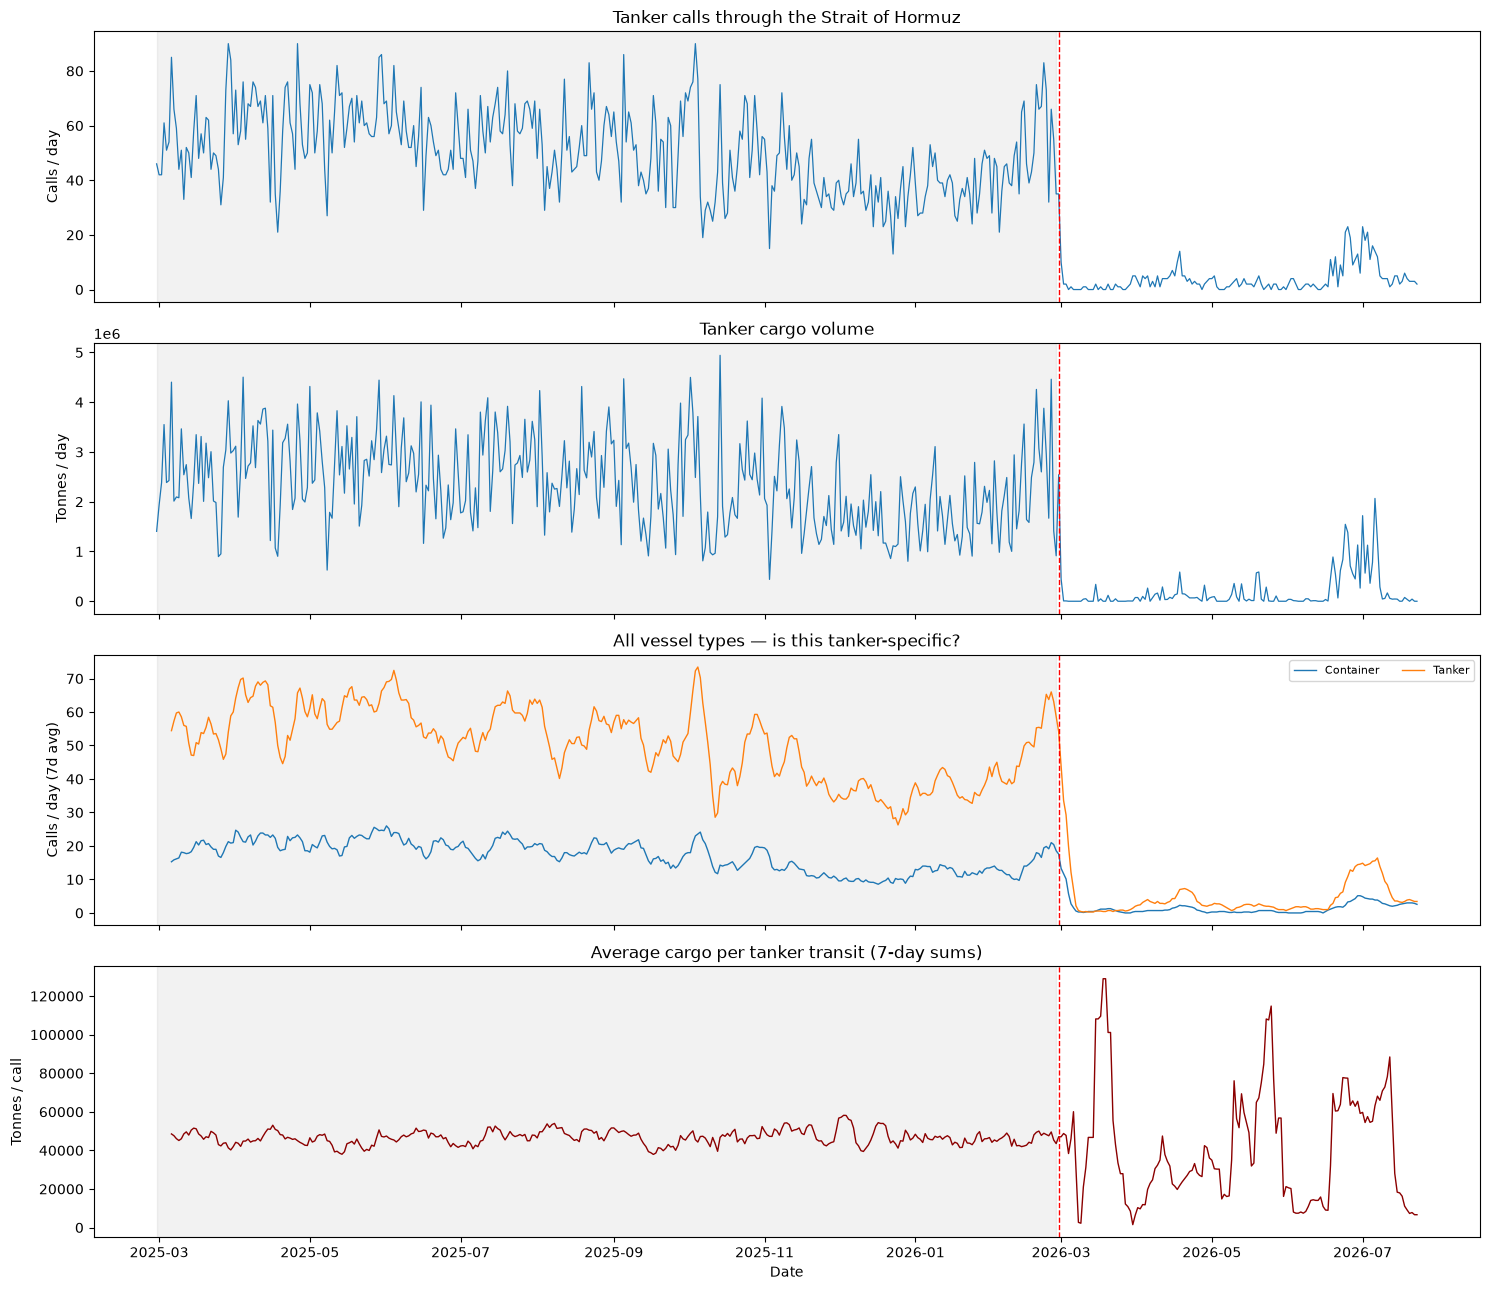

In [96]:
# did the disruption happen and how big? (hormuz-transits-daily)
TRANSITS_CSV = ROOT_DIR / 'data' / 'processed' / 'hormuz-transits-daily.csv'
transits_df = pd.read_csv(TRANSITS_CSV, parse_dates=['DateTime'])

strait_closure = pd.to_datetime('2026-02-28')
end = transits_df['DateTime'].max()
crisis_days = (end - strait_closure).days
crisis = transits_df[transits_df['DateTime'] >= strait_closure]
winter_end = strait_closure - pd.DateOffset(weeks=3)

# Where does the pre-closure run-up begin?
winter = transits_df[
    (transits_df['DateTime'] >= strait_closure - pd.DateOffset(months=3)) &
    (transits_df['DateTime'] <  strait_closure - pd.DateOffset(weeks=3))
]
spike_threshold = winter['Tanker_calls'].quantile(0.90)
run_up = transits_df[
    (transits_df['DateTime'] >= winter_end) &
    (transits_df['DateTime'] < strait_closure) &
    (transits_df['Tanker_calls'] > spike_threshold)
]
spike_start = run_up['DateTime'].min()

# Three baseline definitions 
baselines = {
    'crisis_length': (strait_closure - pd.Timedelta(days=crisis_days),
                      strait_closure - pd.Timedelta(days=1)),
    'pre_spike':     (strait_closure - pd.Timedelta(days=crisis_days),
                      spike_start - pd.Timedelta(days=1)),
    'fixed_year':    (strait_closure - pd.DateOffset(years=1),
                      strait_closure - pd.Timedelta(days=1)),
}
rows = []
for label, (b_start, b_end) in baselines.items():
    assert b_end > b_start, f"{label}: {b_start.date()} → {b_end.date()}"
    base = transits_df[
        (transits_df['DateTime'] >= b_start) & (transits_df['DateTime'] <= b_end)
    ]
    rows.append({
        'baseline': label,
        'start': b_start.date(),
        'end': b_end.date(),
        'days': len(base),
        'calls_before': base['Tanker_calls'].mean(),
        'calls_after': crisis['Tanker_calls'].mean(),
        'calls_ratio': base['Tanker_calls'].mean() / crisis['Tanker_calls'].mean(),
        'vol_ratio': base['Tanker_volume'].mean() / crisis['Tanker_volume'].mean(),
    })
sensitivity = pd.DataFrame(rows).round(2)
print(f"Run-up detected from {spike_start.date()} "
      f"(threshold {spike_threshold:.0f} calls/day)\n")
print(sensitivity.to_string(index=False))

# Plot 
plot_start = baselines['fixed_year'][0]
window = transits_df[
    (transits_df['DateTime'] >= plot_start) & (transits_df['DateTime'] <= end)
].copy()

# 7-day sums
roll_vol = window['Tanker_volume'].rolling(7).sum()
roll_calls = window['Tanker_calls'].rolling(7).sum()
window['vol_per_call'] = (roll_vol / roll_calls).replace([np.inf, -np.inf], np.nan)
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
ax1, ax2, ax3, ax4 = axes
ax1.plot(window['DateTime'], window['Tanker_calls'], linewidth=0.9)
ax1.set_ylabel("Calls / day")
ax1.set_title("Tanker calls through the Strait of Hormuz")
ax2.plot(window['DateTime'], window['Tanker_volume'], linewidth=0.9)
ax2.set_ylabel("Tonnes / day")
ax2.set_title("Tanker cargo volume")

# Is the collapse tanker-specific, or did all shipping stop?
for col in ['Container_calls', 'Dry Bulk_calls', 'General Cargo_calls', 'Tanker_calls']:
    if col in window.columns:
        ax3.plot(window['DateTime'], window[col].rolling(7).mean(),
                 linewidth=1, label=col.replace('_calls', ''))
ax3.set_ylabel("Calls / day (7d avg)")
ax3.set_title("All vessel types — is this tanker-specific?")
ax3.legend(fontsize=8, ncol=4)

# Measurement-error check
ax4.plot(window['DateTime'], window['vol_per_call'], linewidth=1, color='darkred')
ax4.set_ylabel("Tonnes / call")
ax4.set_xlabel("Date")
ax4.set_title("Average cargo per tanker transit (7-day sums)")
for ax in axes:
    ax.axvline(strait_closure, color='red', linestyle='--', linewidth=1)
    ax.axvspan(*baselines['fixed_year'], color='grey', alpha=0.10)
fig.tight_layout()
fig.savefig(FIGS_OUT + "//hormuz-disruption-overview.png", dpi=150)
plt.show()

In [ ]:
# How did flows change? (china-quantities-monthly)
# ~12:1 exposure: China 5.4 vs US 0.43 mb/d Hormuz crude (EIA chokepoints, CrudeByDestination_F5, 1H25)
CHINA_QUANT_DIR = ROOT_DIR / 'data' / 'processed' / 'china-quantities-monthly.csv'

quant_china = pd.read_csv(CHINA_QUANT_DIR, parse_dates=['period'])
strait_closure = pd.to_datetime('2026-02-28')

# fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
# ax1, ax2 = axes
# ax1.plot(quant_china['period'], quant_china['REFINOBS'], linewidth=0.9)
# ax2.plot(quant_china['period'], quant_china['TOTIMPSB'], linewidth=0.9)
# ax1.set_title('Chinese Refinery intakes (Monthly)')
# ax2.set_title('Chinese crude imports (Monthly)')
# ax1.set_ylabel('Refinery Intake (KBD)')
# ax2.set_ylabel('Crude Imports (KBD)')
# for ax in axes:
#     ax.axvline(strait_closure, color='red', linestyle='--', linewidth=1)
# plt.savefig(FIGS_OUT + '\\chinese-quantities-trends.png', dpi=150)
# plt.show()

def ratio(df: pd.DataFrame, col: str, cutoff='2026-01-01', date='period') -> pd.DataFrame:
    """
    Estimate a 12-month seasonal profile from untreated years. Normalises each
    observation by its own year's mean, then collapses across years by calendar
    month; returns 12 rows with 'mean' and 'median' columns (median is robust to
    one anomalous year). Rows on or after `cutoff` are excluded so the treatment
    period cannot contaminate the profile. Multiplicative — invalid for series
    centred near zero (e.g. stock changes), and does not remove within-year trend,
    so a growing series shows a spurious Jan-low/Dec-high tilt.
    """
    pre_filtered = df[df[date] < cutoff].copy()
    pre_filtered['year'] = pre_filtered[date].dt.year
    pre_filtered['ratio'] = pre_filtered[col] / pre_filtered.groupby('year')[col].transform('mean')
    pre_filtered['month'] = pre_filtered[date].dt.month
    return pre_filtered.groupby('month')['ratio'].agg(['mean', 'median'])

window = quant_china[(quant_china['period'] >= '2025-03-01') & (quant_china['period'] <= '2026-02-01')]
window_alt = quant_china[(quant_china['period'] >= '2025-02-01') & (quant_china['period'] <= '2026-01-01')]
def seasonal_impact(df: pd.DataFrame, baseline_df: pd.DataFrame, cols=('REFINOBS', 'TOTIMPSB'), target='2026-04-01'):
    """
    Decompose an observation's gap from baseline into seasonal and residual parts.
    For each column: baseline mean over `baseline_df`, actual at `target`, then
    deseasonalise by dividing out that month's factor. Returns one row per series
    with baseline, raw, seasonal, residual, and seasonal_pct. Sign convention:
    raw = baseline - actual, so positive is a decline; the seasonal component goes
    negative when the target month normally runs above average, widening rather
    than narrowing the estimate. seasonal_pct is suppressed below 1% of baseline.
    Assumes `baseline_df` spans twelve consecutive months so its own factors
    average to 1 and need no adjustment.
    """
    rows = []
    for col in cols: 
        ratios = ratio(df, col)
        baseline = baseline_df[col].mean()
        actual = df.loc[df['period'] == target, col].iloc[0]
        factor = ratios.loc[pd.Timestamp(target).month, 'mean']
        adjusted = actual / factor
        raw = baseline - actual
        seasonal = adjusted - actual
        residual = raw - seasonal
        rows.append({'series': col, 'baseline': round(baseline, 2), 'raw': round(raw, 2),
                     'seasonal': round(seasonal, 2), 'residual': round(residual, 2), 'seasonal_pct': round(100 * seasonal/raw, 2) if abs(raw) > 0.01 * baseline else None})
    return pd.DataFrame(rows).set_index('series')

impact_base = seasonal_impact(quant_china, window)
impact_alt = seasonal_impact(quant_china, window_alt)
impact_base_alt = pd.concat([impact_base, impact_alt], keys=['Mar25-Feb26', 'Feb25-Jan26'])

# intake - imports must represent crude entering refinery from domestic sources
quant_china['crude_balance_gap'] = quant_china['REFINOBS'] - quant_china['TOTIMPSB']

seasonal_impact(quant_china, window, target='2026-03-01')
seasonal_impact(quant_china, window, target='2026-05-01')

In [ ]:
# How did flows change? Part 2 (us-quantities-weekly.csv, us-crude-imports-by-origin-monthly.csv)
# ~12:1 exposure: China 5.4 vs US 0.43 mb/d Hormuz crude (EIA chokepoints, CrudeByDestination_F5, 1H25)
US_QUANT_DIR = ROOT_DIR / 'data' / 'processed' / 'us-quantities-weekly.csv'
US_IMPORT_DIR = ROOT_DIR / 'data' / 'processed' / 'us-crude-imports-by-origin-monthly.csv'

quant_us = pd.read_csv(US_QUANT_DIR, parse_dates=['date'])
strait_closure = pd.to_datetime('2026-02-28')
quant_us.drop(columns=[c for c in quant_us.columns if c.startswith('product')], inplace=True)

quant_us['SPR_chg_kbd'] = quant_us['crude_stocks_spr_kbbl'].diff() / 7
quant_us['EX_SPR_chg_kbd'] = quant_us['crude_stocks_ex_spr_kbbl'].diff() / 7  
# aggregate to monthly to reuse ratio and seasonal_impact helper functions
# last for _kbbl cols and day weighted mean for _kbd cols
us_daily = quant_us.set_index('date')
day_range = pd.date_range(start='2019-01-01', end='2026-07-24', freq='D')
us_daily = us_daily.reindex(day_range).bfill()
rate_cols = [c for c in quant_us.columns if c.endswith('_kbd')]
level_cols = [c for c in quant_us.columns if c.endswith('_kbbl')]
rates = us_daily.groupby(us_daily.index.to_period('M'))[rate_cols].mean()
levels = quant_us.groupby(quant_us['date'].dt.to_period('M'))[level_cols].last()
us_monthly = pd.concat([rates, levels], axis=1)

# refinery input ≈ production + imports − exports + stock draw (SPR + commercial)
# fig, axes = plt.subplots(3, 1, figsize=(10,6), sharex=True, tight_layout=True)
# ax1, ax2, ax3 = axes
# ax1.plot(us_monthly.index.to_timestamp(), us_monthly['crude_imports_kbd'], linewidth=0.9)
# ax2.plot(us_monthly.index.to_timestamp(), us_monthly['refinery_input_kbd'], linewidth=0.9)
# ax3.plot(us_monthly.index.to_timestamp(), us_monthly['SPR_chg_kbd'], linewidth=0.9)
# ax1.set_title('US Crude imports trend over time')
# ax1.set_ylabel('Crude imports (KBD)')
# ax2.set_title('US Refinery inputs trend over time')
# ax2.set_ylabel('Refinery inupts (KBD)')
# ax3.set_title('Change in Strategic Petroleum Reserves')
# ax3.set_ylabel('SPR draw/build (kb/d)')
# for ax in axes:
#     ax.axvline(strait_closure, color='red', linestyle='--', linewidth=1)
# plt.savefig(FIGS_OUT + '//us-quantities-trend.png', dpi=150)
# plt.show()

window = us_monthly[(us_monthly.index <= '2026-02-01') & (us_monthly.index >= '2025-03-01')]
window_alt = us_monthly[(us_monthly.index <= '2026-01-01') & (us_monthly.index >= '2025-02-01')]
baseline = window.mean()
window_2026 = us_monthly[us_monthly.index >= '2026-03-01']
deviation = window_2026 - baseline
deviation.drop(columns=[c for c in deviation.columns if c.endswith('_kbbl')], inplace=True)

# fig, ax = plt.subplots(figsize=(10,6), tight_layout=True)
# labels = {'crude_imports_kbd' : 'Imports', 'crude_production_kbd': 'Production', 
#           'crude_exports_kbd': 'Exports', 'refinery_input_kbd': 'Refinery', 
#           'SPR_chg_kbd': 'SPR (Stock Draw)', 'EX_SPR_chg_kbd': 'Commerical (Stock Draw)'}
# deviation.rename(columns=labels).plot(kind='bar', ax=ax)
# ax.axhline(0, color='black', linewidth=0.8)
# ax.tick_params(axis='x', rotation=0)
# ax.set_title('US Crude flow deviations from Mar 2025 - Feb 2026 baseline')
# ax.set_ylabel('Deviation from baseline (kb/d)')
# plt.legend(loc='lower left')
# plt.savefig(FIGS_OUT + '//us-quantities-bar.png')
# plt.show()

pre_baseline = us_monthly[us_monthly.index < '2026-01-01'].copy()
stds = round(pre_baseline.diff().std(), 2)
deviation_sigma = deviation / stds

us_monthly = us_monthly.reset_index().rename(columns={'index' : 'period'})
ratio(us_monthly[us_monthly['period'] >= '2023-01-01'], 'crude_imports_kbd')
ratio(us_monthly[us_monthly['period'] >= '2023-01-01'], 'crude_exports_kbd')
ratio(us_monthly[us_monthly['period'] >= '2023-01-01'], 'refinery_input_kbd')

cols = ('crude_imports_kbd', 'crude_exports_kbd', 'refinery_input_kbd')
impact_base = seasonal_impact(us_monthly, window, cols=cols)
impact_alt = seasonal_impact(us_monthly, window_alt, cols=cols)
impact_base_alt = pd.concat([impact_base, impact_alt], keys=['Mar25-Feb26', 'Feb25-Jan26'])
impact_base_alt_std = impact_base_alt.diff().std()

# limitation: many countries have different routes to bypass the strait of hormuz, this dataset doesn't identify this
# units: MBBL
us_im_origin = pd.read_csv(US_IMPORT_DIR, parse_dates=['period'])
gulf_origin = ['SAU', 'IRQ', 'KWT', 'ARE']
filtered_origin = us_im_origin[(us_im_origin['area-name'].isin(gulf_origin)) & (us_im_origin['is_aggregate'] == False)].copy()
gulf = filtered_origin.groupby('period')['value'].sum()
gulf_kbd = gulf / gulf.index.days_in_month
gulf_kbd = gulf_kbd.reset_index()
gulf_kbd.rename(columns={0:'gulf_imports_kbd'}, inplace=True)
gulf_window = gulf_kbd[(gulf_kbd['period'] <= '2026-02-01') & (gulf_kbd['period'] >= '2025-03-01')]
gulf_window_alt = gulf_kbd[(gulf_kbd['period'] <= '2026-01-01') & (gulf_kbd['period'] >= '2025-02-01')]
gulf_impact = seasonal_impact(gulf_kbd, gulf_window, cols=['gulf_imports_kbd'], target='2026-05-01')
gulf_impact_alt = seasonal_impact(gulf_kbd, gulf_window_alt, cols=['gulf_imports_kbd'], target='2026-05-01')
gulf_impact_base_alt = pd.concat([gulf_impact, gulf_impact_alt], keys=['Mar25-Feb26', 'Feb25-Jan26'])
gulf_impact_base_alt

,,baseline,raw,seasonal,residual,seasonal_pct
,series,,,,,
Mar25-Feb26,gulf_imports_kbd,524.60,338.11,-15.94,354.05,-4.72
Feb25-Jan26,gulf_imports_kbd,494.85,308.36,-15.94,324.30,-5.17


### Flow disruption: China vs US

**China.** March 2026 is indistinguishable from the fixed baseline (0.5% and 2.1%, seasonally adjusted) — consistent with the 3–4 week Gulf-to-China shipping lag. By May, crude imports were 4,057 kb/d below baseline (−34.2%) and refinery intake 4,138 kb/d (−25.6%). The intake-minus-imports gap stayed flat through April–May, so refiners cut runs in proportion to the shortfall rather than drawing down stocks: the shock passed straight through to refining activity.

**US.** Total crude imports show no detectable effect — every monthly deviation falls under 2σ against a month-over-month noise floor of 340 kb/d. That is a power limit, not a null: with maximum Hormuz exposure of 430 kb/d, even a complete loss would register at only 1.3σ in this series. Disaggregating by origin resolves it — Gulf-origin imports (SAU, IRQ, KWT, ARE) fell 65–68% in May 2026, 2.1–2.3σ, robust across both baseline windows. The US adjusted through other channels instead: crude exports rose 1,411 kb/d (4.2σ) and the SPR was drawn at 1,300 kb/d, exceeding the 2022 release.

**Comparison.** China's total-import decline is ~11.5× the US Gulf-origin decline, close to the 12.6:1 Hormuz exposure ratio — but these are not like-for-like measures (China total vs US Gulf-only), since no free source provides China crude imports by origin, so the correspondence is suggestive only.

In [ ]:
# How did composition change? (us-crude-imports-by-origin-monthly), partly done from previous cell where we see gulf-origin imports falling by ~65%
# now which imports replaced the fall from the gulf origin? Canada? total imports were null so it must have been substituted from someplace else. 
strait_closure = pd.to_datetime('2026-02-28')

filtered_origin = us_im_origin[~us_im_origin['is_aggregate']].copy()
region_map = {
    # Gulf — transits Hormuz
    'SAU':'Gulf','IRQ':'Gulf','KWT':'Gulf','ARE':'Gulf','QAT':'Gulf','IRN':'Gulf',
    # North America
    'CAN':'North America','MEX':'North America',
    # Latin America & Caribbean
    'COL':'Latin America','BRA':'Latin America','ECU':'Latin America','GUY':'Latin America',
    'VEN':'Latin America','ARG':'Latin America','TTO':'Latin America','PER':'Latin America',
    'GTM':'Latin America','PAN':'Latin America','BHS':'Latin America','BLZ':'Latin America',
    # West & Central Africa
    'NGA':'West Africa','AGO':'West Africa','GHA':'West Africa','CMR':'West Africa',
    'COG':'West Africa','GAB':'West Africa','GNQ':'West Africa','CIV':'West Africa',
    'COD':'West Africa','SEN':'West Africa','TCD':'West Africa','NA':'West Africa',
    # North Africa
    'LBY':'North Africa','DZA':'North Africa','EGY':'North Africa','TUN':'North Africa',
    # Europe
    'GBR':'Europe','NOR':'Europe','DNK':'Europe','NLD':'Europe','ITA':'Europe','ESP':'Europe',
    # Eurasia
    'RUS':'Eurasia','KAZ':'Eurasia',
    # Asia-Pacific
    'BRN':'Asia-Pacific','AUS':'Asia-Pacific','IDN':'Asia-Pacific','VNM':'Asia-Pacific',
}
filtered_origin['region'] = filtered_origin['area-name'].map(region_map)
substitute = filtered_origin.groupby(['region', 'period'])['value'].sum()
wide = substitute.unstack('region')
wide.fillna(0, inplace=True)
wide_kbd = wide.div(wide.index.days_in_month, axis=0)
wide_kbd_shares = wide_kbd.div(wide_kbd.sum(axis=1), axis=0)

# fig, ax = plt.subplots(figsize=(10,6))
# wide_kbd_shares.plot(ax=ax)
# ax.axvline(strait_closure, color='black', linestyle='--', linewidth=0.9)
# ax.set_title('US Crude import composition by origin region')
# ax.set_ylabel('Share of US Crude imports')
# plt.savefig(FIGS_OUT + '//us-crude-import-composition.png')
# plt.show()

cols = ('Asia-Pacific', 'Eurasia', 'Europe', 'Gulf', 'Latin America', 'North Africa', 'North America', 'West Africa')
origin_window = wide_kbd[(wide_kbd.index <= '2026-02-01') & (wide_kbd.index >= '2025-03-01')]
origin_window_alt = wide_kbd[(wide_kbd.index <= '2026-01-01') & (wide_kbd.index >= '2025-02-01')]
wide_kbd_std = wide_kbd.diff().std()
wide_kbd_seasonal = wide_kbd.reset_index('period')
origin_impact_base = seasonal_impact(wide_kbd_seasonal, origin_window, cols=cols, target='2026-05-01')
origin_impact_alt = seasonal_impact(wide_kbd_seasonal, origin_window_alt, cols=cols, target='2026-05-01')
origin_impact_base_alt = pd.concat([origin_impact_base, origin_impact_alt], keys=['Mar25-Feb26', 'Feb25-Jan26'])
origin_impact_base_alt # positive is decline, negative is increase

baseline     raw  seasonal  residual  seasonal_pct
            series                                                           
Mar25-Feb26 Asia-Pacific       0.00    0.00      0.00      0.00           NaN
            Eurasia           28.25   28.25      0.00     28.25          0.00
            Europe            57.63   20.63     -8.85     29.48        -42.89
            Gulf             524.60  338.11    -15.46    353.57         -4.57
            Latin America   1027.28 -399.07     21.17   -420.24         -5.30
            North Africa      79.82   46.69      1.77     44.92          3.79
            North America   4247.80   87.64     38.73     48.91         44.19
            West Africa      221.25  111.16    -14.39    125.55        -12.95
Feb25-Jan26 Asia-Pacific       0.00    0.00      0.00      0.00           NaN
            Eurasia           28.25   28.25      0.00     28.25          0.00
            Europe            59.82   22.82     -8.85     31.67        -38.77
            Gulf             494.85  308.36    -15.46    323.82         -5.01
            Latin America   1014.23 -412.12     21.17   -433.29         -5.14
            North Africa      73.03   39.90      1.77     38.13          4.44
            North America   4270.37  110.20     38.73     71.48         35.14
            West Africa      211.73  101.64    -14.39    116.03        -14.16

### Composition: where the substitution went

Gulf-origin crude (SAU, IRQ, KWT, ARE) fell 354 kb/d in May 2026 — 2.3σ, a two-thirds decline, robust across both baseline windows. Latin America absorbed all of it and more, up 420 kb/d (3.2σ), while every other region fell. North America was flat at 0.19σ despite supplying 4,248 kb/d at baseline — eight times the Gulf's volume and more than enough spare capacity to cover the gap. Substitution went to heavy-sour Latin American crude rather than to the largest and nearest supplier, which points to grade compatibility rather than volume availability as the binding constraint on Gulf Coast refiners. West Africa fell 126 kb/d (1.55σ, suggestive only).

*Limitation:* origin is not route. Saudi and UAE barrels can reach open water via the Yanbu and Fujairah pipelines, so Gulf-origin is an upper bound on Hormuz-transiting volume, and part of the observed decline may be rerouting that this data cannot distinguish from lost supply.

In [ ]:
# pass-through to pump prices? (crude-prices-daily, us-retail-prices-weekly, china-retail-prices-events)
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

CHINA_PRICES = ROOT_DIR / 'data' / 'processed' / 'china-retail-prices-events.csv'
US_PRICES = ROOT_DIR / 'data' / 'processed' / 'us-retail-prices-weekly.csv'
CRUDE_PRICES = ROOT_DIR / 'data' / 'processed' / 'crude-prices-daily.csv'

china_prices = pd.read_csv(CHINA_PRICES, parse_dates=['adjustment_date', 'effective_date'])
us_prices = pd.read_csv(US_PRICES, parse_dates=['date'])
crude_prices = pd.read_csv(CRUDE_PRICES, parse_dates=['observation_date'])
strait_closure = pd.to_datetime('2026-02-28')

# align us_prices and crude_prices
tmp = crude_prices.set_index('observation_date')
resample_crude = tmp.resample('W-FRI').mean()
resample_crude.index = resample_crude.index + pd.Timedelta(days=3)
resample_crude.index.rename('date', inplace=True)
merged_crude_us = pd.merge(resample_crude, us_prices, on='date', how='inner')
merged_crude_us = merged_crude_us.set_index('date')

diffed = merged_crude_us.diff()
diffed.dropna(inplace=True)
columns = ('DCOILBRENTEU', 'DCOILWTICO', 'gasoline_regular_usd_gal', 'diesel_ulsd_usd_gal')
rows = []
for col in columns:
    adf_test_levels = adfuller(merged_crude_us[col])
    adf_test_diff = adfuller(diffed[col])
    rows.append({
        'series' : col,
        'level_p' : adf_test_levels[1],
        'diff_p' : adf_test_diff[1]
    })
adf_df = pd.DataFrame(rows).set_index('series') # fails to reject null (non-stationary) in levels, but rejects decisively in first difference

# ols regression (brent, wti) x (gasoline, diesel); 4 seperate OLS regression
def build_lags(df:pd.DataFrame, benchmark:str, n=9):
    """Lag matrix of a differenced crude series, lags 0 to n-1."""
    return pd.DataFrame({f'{benchmark}_lag{i}': df[benchmark].shift(i) for i in range(n)})

def cumulative_passthrough(df:pd.DataFrame, product:str, benchmark:str) -> dict:
    """
    Estimate cumulative pass-through from a crude benchmark to a retail fuel price.
    Regresses the weekly change in `product` on weekly changes in `benchmark` at lags
    0-8, in first differences, with HAC standard errors (maxlags=8). Returns the summed
    lag coefficients in $/gal per $/bbl — compare against 1/42 = 0.0238 for full
    mechanical pass-through — plus its standard error and the fitted results object.
    """
    y = df[product]
    X = build_lags(df, benchmark)
    merged_df = pd.concat([y, X], axis=1).dropna()
    y_clean = merged_df[y.name]
    X_clean = sm.add_constant(merged_df.drop(columns=y.name))
    res = sm.OLS(y_clean, X_clean).fit(cov_type='HAC', cov_kwds={'maxlags' : 8})
    cumulative = res.params.drop('const').sum()
    contrast = np.zeros(len(res.params))
    contrast[1:] = 1
    t = res.t_test(contrast)
    assert np.isclose(t.effect, cumulative)
    return {
        'product' : product, 
        'benchmark' : benchmark, 
        'cumulative' : cumulative,
        'n_obs' : int(res.nobs), 
        'r_squared' : res.rsquared, 
        'cum_se' : t.sd[0][0],
        'res' : res
    }

combos = (
    ('gasoline_regular_usd_gal', 'DCOILBRENTEU'), 
    ('gasoline_regular_usd_gal', 'DCOILWTICO'), 
    ('diesel_ulsd_usd_gal', 'DCOILBRENTEU'), 
    ('diesel_ulsd_usd_gal', 'DCOILWTICO')
)
pre_closure = diffed[diffed.index < strait_closure]
ols_results = pd.DataFrame([cumulative_passthrough(pre_closure, p, b) for p, b in combos])

def counterfactual(
        diffed: pd.DataFrame,
        us_prices: pd.DataFrame,
        res: sm.regression.linear_model.RegressionResultsWrapper,
        product: str, 
        benchmark: str, 
        start: str = '2026-03-02',
    ) -> pd.DataFrame:
    """
    Project a pre-crisis pass-through model onto the crisis window and measure the gap.
    Applies `res` to crisis-period crude changes, cumulates the predicted changes from the
    last pre-crisis retail level, and returns a date-indexed frame of predicted and actual
    weekly changes and levels with both residuals. No estimation on crisis data.
    """
    X_all = build_lags(diffed, benchmark)
    X_crisis = sm.add_constant(X_all[X_all.index >= start])
    predicted = res.predict(X_crisis)
    us_lvl = us_prices.set_index('date')
    anchor = us_lvl.loc[us_lvl.index < start, product].iloc[-1]
    pred_lvl_path = anchor + predicted.cumsum()
    actual_lvl_path = us_lvl.loc[start:, product]
    actual_chg_path = diffed.loc[start:, product]
    lvl_residual = actual_lvl_path - pred_lvl_path
    chg_residual = actual_chg_path - predicted
    return pd.DataFrame({
        'pred_chg' : predicted,
        'actual_chg' : actual_chg_path, 
        'chg_residual' : chg_residual,
        'pred_lvl' : pred_lvl_path,
        'actual_lvl' : actual_lvl_path,
        'lvl_residual' : lvl_residual
    })

frames = {}
summary_rows = []
resid_series = []
keys = []
for _, row in ols_results.iterrows():
    key = f"{row['product']}_{row['benchmark']}"
    cf = counterfactual(diffed, us_prices, row['res'], row['product'], row['benchmark'])

    frames[key] = cf
    resid_series.append(cf['lvl_residual'])
    keys.append(key)

    r = cf['chg_residual']
    summary_rows.append({
        'product' : row['product'], 
        'benchmark' : row['benchmark'], 
        'final_lvl_gap' : cf['lvl_residual'].iloc[-1],
        'mean_chg_resid' : r.mean(),
        't_stat' : r.mean() / (r.std() / np.sqrt(len(r))),
        'resid_sd' : r.std(),
        'top3_share' : r.reindex(r.abs().sort_values(ascending=False).index).head(3).sum() / r.sum(),
    })

cf_summary = pd.DataFrame(summary_rows)
cf_resid = pd.concat(resid_series, axis=1, keys=keys)

china_prices['gasoline_cf_change'] = china_prices['gasoline_implied_change_yuan_t'].fillna(china_prices['gasoline_change_yuan_t'])
china_prices['diesel_cf_change'] = china_prices['diesel_implied_change_yuan_t'].fillna(china_prices['diesel_change_yuan_t'])
filt = china_prices[china_prices['adjustment_date'] >= '2026-02-24']
filt.set_index('adjustment_date', inplace=True)
cols = ('gasoline', 'diesel')

out = {}
for p in cols: 
    anchor = china_prices.loc[china_prices['adjustment_date'] == '2026-02-03', f'beijing_{p}_yuan_t'].iloc[0]
    out[f'{p}_actual'] = anchor + filt[f'{p}_change_yuan_t'].cumsum()
    out[f'{p}_cf'] = anchor + filt[f'{p}_cf_change'].cumsum()
    out[f'{p}_wedge'] = out[f'{p}_cf'] - out[f'{p}_actual']

china_paths = pd.DataFrame(out)

CNY_USD = ROOT_DIR / 'data' / 'raw' / 'exchange_rates'
# convert to yuan/tonne to $/bbl, comparable to US side
from fredapi import Fred
import os
from dotenv import load_dotenv

load_dotenv()

fred = Fred(api_key=os.getenv('FRED_API_KEY'))
s = fred.get_series('DEXCHUS', observation_start='2019-01-01')
df = s.reset_index()
df.columns = ['observation_date', 'cny_per_usd']
df.to_csv(CNY_USD / 'cny_usd_exchange_rate.csv', index=False)

BBL_PER_TONNE = {'gasoline' : 8.5, 'diesel' : 7.45}
CNY_PER_USD = df.loc[(df['observation_date'] >= '2026-03-01') & (df['observation_date'] < '2026-05-01'), 'cny_per_usd'].mean()

rows=[]
for p in cols:
    actual_sum

6.8821
